In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

# Load processed spatial datasets
bike_lanes = gpd.read_file("./processed_data/bike_lanes.geojson")
bus_lines = gpd.read_file("./processed_data/bus_lines.geojson")

print("Bike lanes:")
print(bike_lanes.shape)
print(bike_lanes.columns.tolist())

print("\nBus lines:")
print(bus_lines.shape)
print(bus_lines.columns.tolist())

#Check CRS
print("Bike lane CRS:", bike_lanes.crs)
print("Bus line CRS:", bus_lines.crs)

Bike lanes:
(354, 10)
['intervention_id', 'road_name', 'road_side', 'trial_start', 'trial_end', 'lga', 'trial_infrastructure', 'post_infrastructure', 'trial_duration_days', 'geometry']

Bus lines:
(3133, 6)
['SHAPE_ID', 'HEADSIGN', 'SHORT_NAME', 'LONG_NAME', 'MODE', 'geometry']
Bike lane CRS: EPSG:4326
Bus line CRS: EPSG:4326


In [17]:
#convert CRS to EPSG:7855
bike_map = bike_lanes.to_crs(epsg=7855)
bus_map = bus_lines.to_crs(epsg=7855)

# Visualization for all bus routes and popup bike lanes

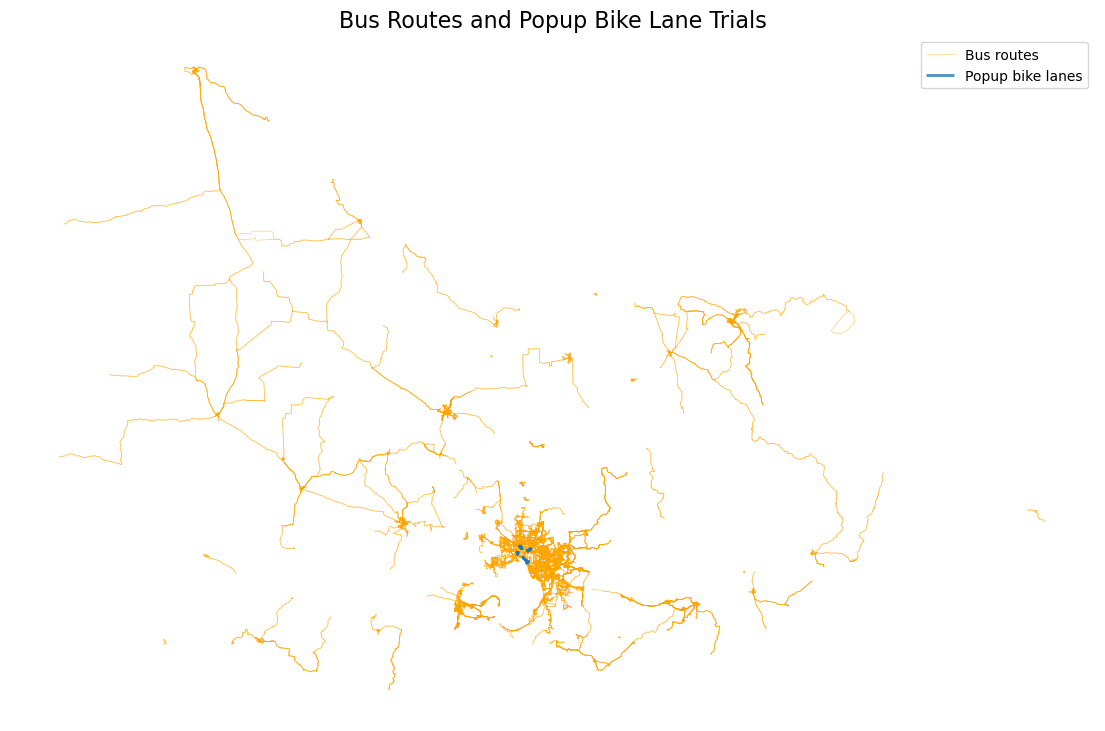

In [26]:
fig, ax = plt.subplots(figsize=(14, 14))

# Bus routes
bus_map.plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.5,
    label="Bus routes",
    color="orange"
)

# Popup bike lanes
bike_map.plot(
    ax=ax,
    linewidth=2,
    alpha=0.8,
    label="Popup bike lanes"
)
ax.set_title(
    "Bus Routes and Popup Bike Lane Trials",
    fontsize=16
)
ax.set_axis_off()
ax.legend()
plt.show()

# Identify bus routes near each bike lane

In [19]:
# createa GeoDataFrame of 100m around bike lane
from geopandas import GeoDataFrame

# create a GeoDataFrame of 100m around bike lane
bike_buffers = GeoDataFrame(
    bike_map[["intervention_id", "road_name", "trial_start", "trial_end"]].copy(),
    geometry=bike_map.geometry.buffer(100),
    crs=bike_map.crs,  # preserve the original CRS
)

# Find bus routes inside the bike-lane influence zones

In [21]:
affected_routes = gpd.sjoin(
    bus_map,
    bike_buffers,
    how="inner",
    predicate="intersects"
)

print(affected_routes.shape)

print(
    affected_routes[
        [
            "SHAPE_ID",
            "SHORT_NAME",
            "LONG_NAME",
            "intervention_id",
            "road_name"
        ]
    ].head(20)
)

(2302, 11)
             SHAPE_ID SHORT_NAME                                   LONG_NAME  \
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
109  17-234-aus-1.2.R        234  Garden City - City (Queen Victoria Market)   
110  17-234-aus-1.3.H        234  Garden City - City (Queen Victoria Market)   
110  17-234-aus-1.3.H        

# NUmber of bike-lane bus-route relationship

In [22]:
# Drop duplicate
affected_route_table = (
    affected_routes[
        [
            "intervention_id",
            "road_name",
            "trial_start",
            "trial_end",
            "SHAPE_ID",
            "SHORT_NAME",
            "LONG_NAME"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(affected_route_table.head(20))
print(
    "Number of bike-lane/bus-route relationships:",
    len(affected_route_table)
)

    intervention_id       road_name trial_start  trial_end          SHAPE_ID  \
0               213  Liardet Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
1                70  Liardet Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
2               185    Lyons Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
3                45    Lyons Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
4                63   Bridge Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
5               205   Bridge Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
6               338   Bridge Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
7               337   Bridge Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
8                14   Bridge Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
9               150   Bridge Street  2022-07-01 2023-07-01  17-234-aus-1.2.R   
10              213  Liardet Street  2022-07-01 2023-07-01  17-234-aus-1.3.H   
11               70  Liardet Street  202

# Visualize only affected bus routes

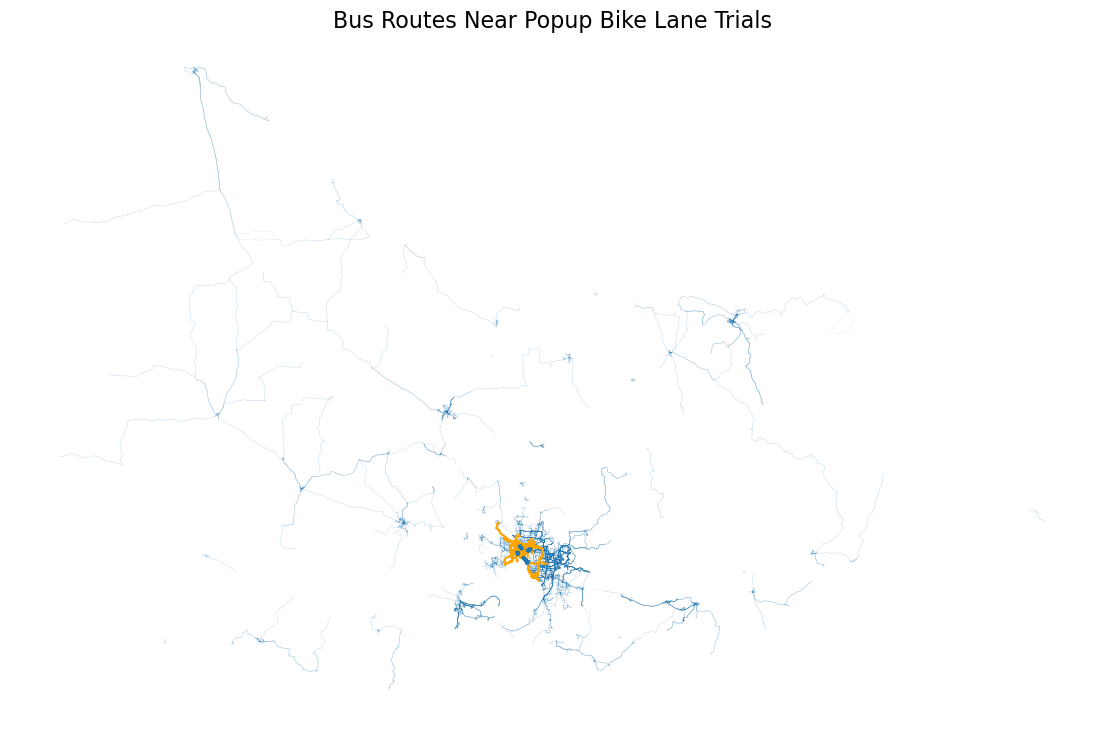

In [27]:
affected_route_ids = affected_routes["SHAPE_ID"].unique()

affected_bus_map = bus_map[
    bus_map["SHAPE_ID"].isin(affected_route_ids)
].copy()

fig, ax = plt.subplots(figsize=(14, 14))

# All bus routes in background
bus_map.plot(
    ax=ax,
    linewidth=0.3,
    alpha=0.15
)

# Affected bus routes
affected_bus_map.plot(
    ax=ax,
    linewidth=1.2,
    alpha=0.8,
    color="orange"
)

# Bike lanes
bike_map.plot(
    ax=ax,
    linewidth=2.5,
    alpha=0.9
)

ax.set_title(
    "Bus Routes Near Popup Bike Lane Trials",
    fontsize=16
)

ax.set_axis_off()

plt.show()

# Plot individual intervention areas

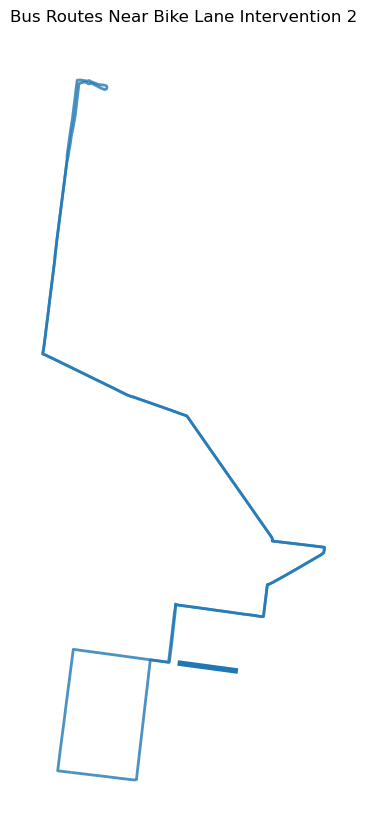

In [24]:
intervention_id = 2

bike = bike_map[
    bike_map["intervention_id"] == intervention_id
]

nearby = affected_bus_map[
    affected_bus_map["SHAPE_ID"].isin(
        affected_routes[
            affected_routes["intervention_id"] == intervention_id
        ]["SHAPE_ID"]
    )
]

#visualize
fig, ax = plt.subplots(figsize=(10, 10))

nearby.plot(
    ax=ax,
    linewidth=2,
    alpha=0.8
)

bike.plot(
    ax=ax,
    linewidth=4,
    alpha=1
)

ax.set_title(
    f"Bus Routes Near Bike Lane Intervention {intervention_id}"
)

ax.set_axis_off()

plt.show()